In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
from scipy import stats
sns.set_context('talk')

In [2]:
data_dir = r'C:\Users\tiffany.ona\Documents\working_memory\data\1.7. Review_Check if there are stimulus-disengaged'

merged_delay3  = pd.read_csv(data_dir + r'\merged_all_delay3.csv')
merged_delay10 = pd.read_csv(data_dir + r'\merged_all.csv')

In [3]:
def plot_stim_wm_figure(merged_all, delay, save_svg=None):
    wm_neg_delay = merged_all.query("condition == 'wm_neg_delay'")
    wm_pos_delay = merged_all.query("condition == 'wm_pos_delay'")
    sti_neg      = merged_all.query("condition == 'sti_neg'")
    sti_pos      = merged_all.query("condition == 'sti_pos'")

    scatter_data = (
        pd.concat([wm_neg_delay, wm_pos_delay])
        .drop_duplicates(subset=['session', 'trial'])
        [['log_odds_delay', 'log_odds_sti']]
        .dropna()
    )

    # Explicit axes positions [x0, y0, w, h] in figure fraction.
    # figsize = 15 × 7 inches.
    # Scatter box: 0.336 × 0.72 fig-frac = 5.04 × 5.04 inches  (exact square).
    # Time-series axes span the same y-range [0.12, 0.84] as the scatter:
    #   - bottom row: y=[0.12, 0.42],  top row: y=[0.54, 0.84]  (0.12 gap for x-labels)
    fig = plt.figure(figsize=(15, 7))
    ax_sc = fig.add_axes([0.11, 0.12, 0.336, 0.72])
    ax_tl = fig.add_axes([0.54, 0.54, 0.20,  0.30])
    ax_tr = fig.add_axes([0.78, 0.54, 0.20,  0.30])
    ax_bl = fig.add_axes([0.54, 0.12, 0.20,  0.30])
    ax_br = fig.add_axes([0.78, 0.12, 0.20,  0.30])

    # --- Panel a: scatter ---
    sns.regplot(
        x='log_odds_delay', y='log_odds_sti', data=scatter_data,
        color='black', ax=ax_sc, marker='o',
        scatter_kws={'s': 60, 'edgecolor': 'white', 'linewidths': 0.4, 'alpha': 0.75},
        line_kws={'color': 'black'}
    )
    res = stats.linregress(scatter_data['log_odds_delay'], scatter_data['log_odds_sti'])
    r, p = res.rvalue, res.pvalue
    p_str = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
    ax_sc.text(0.05, 0.97, f'r = {r:.2f}\n{p_str}',
               transform=ax_sc.transAxes, va='top', ha='left', fontsize=9)
    ax_sc.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax_sc.axvline(0, color='goldenrod', linewidth=2.5)

    ylim = ax_sc.get_ylim()
    y_top = ylim[1] * 0.93
    ax_sc.text(-0.3, y_top, 'Reversals',       ha='right', color='goldenrod',
               fontsize=11, fontweight='bold')
    ax_sc.text( 0.3, y_top, 'Loading\nerrors', ha='left',  color='goldenrod',
               fontsize=11, fontweight='bold')
    ax_sc.set_xlabel('Choice Decoding Accuracy\nDelay code (log-odds)')
    ax_sc.set_ylabel('Stimulus Decoding Accuracy\nStimulus code (log-odds)')
    ax_sc.text(-0.15, 1.04, 'a', transform=ax_sc.transAxes,
               fontsize=14, fontweight='bold')

    # --- Panel b: 2×2 time series ---
    panels = [
        (ax_tl, sti_neg,      'crimson', 'Stimulus Code',
         'Stimulus Decoding\nAccuracy (log-odds)'),
        (ax_tr, sti_pos,      'darkred', 'Stimulus Code',  ''),
        (ax_bl, wm_neg_delay, 'crimson', 'WM Delay',
         'Choice Decoding\nAccuracy (log-odds)'),
        (ax_br, wm_pos_delay, 'darkred', 'WM Delay',       ''),
    ]

    for ax, df_data, color, title, ylabel in panels:
        df_ts = (
            df_data.loc[df_data.trial_type == 'WM_roll_0']
            .groupby(['session', 'times', 'trial_type'])['log_odds']
            .mean().reset_index()
        )
        sns.lineplot(
            x='times', y='log_odds', data=df_ts,
            color=color, ax=ax, errorbar='se',
            err_kws={'edgecolor': 'none'}, legend=False
        )
        ax.set_ylim(-4, 4)
        ax.set_xlim(-2, delay + 4)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.axvspan(0,            0.35,        color='gray', alpha=0.2, linewidth=0)
        ax.axvspan(delay + 0.3,  delay + 0.5, color='gray', alpha=0.2, linewidth=0)
        ax.set_xlabel('Time from stimulus onset (s)')
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    # Column headers above top row
    for ax, label in [(ax_tl, 'Reversals'), (ax_tr, 'Loading errors')]:
        ax.annotate(label, xy=(0.5, 1.20), xycoords='axes fraction',
                    ha='center', va='bottom', fontsize=12, color='crimson', fontweight='bold')
    ax_tl.text(-0.28, 1.25, 'b', transform=ax_tl.transAxes,
               fontsize=14, fontweight='bold')

    # Gold separator between the two right columns
    fig.add_artist(
        mlines.Line2D([0.76, 0.76], [0.10, 0.92],
                      transform=fig.transFigure,
                      color='goldenrod', linewidth=3, zorder=10)
    )

    sns.despine(fig=fig)

    if save_svg:
        plt.savefig(save_svg, format='svg', dpi=300, bbox_inches='tight')
    plt.show()
    return fig

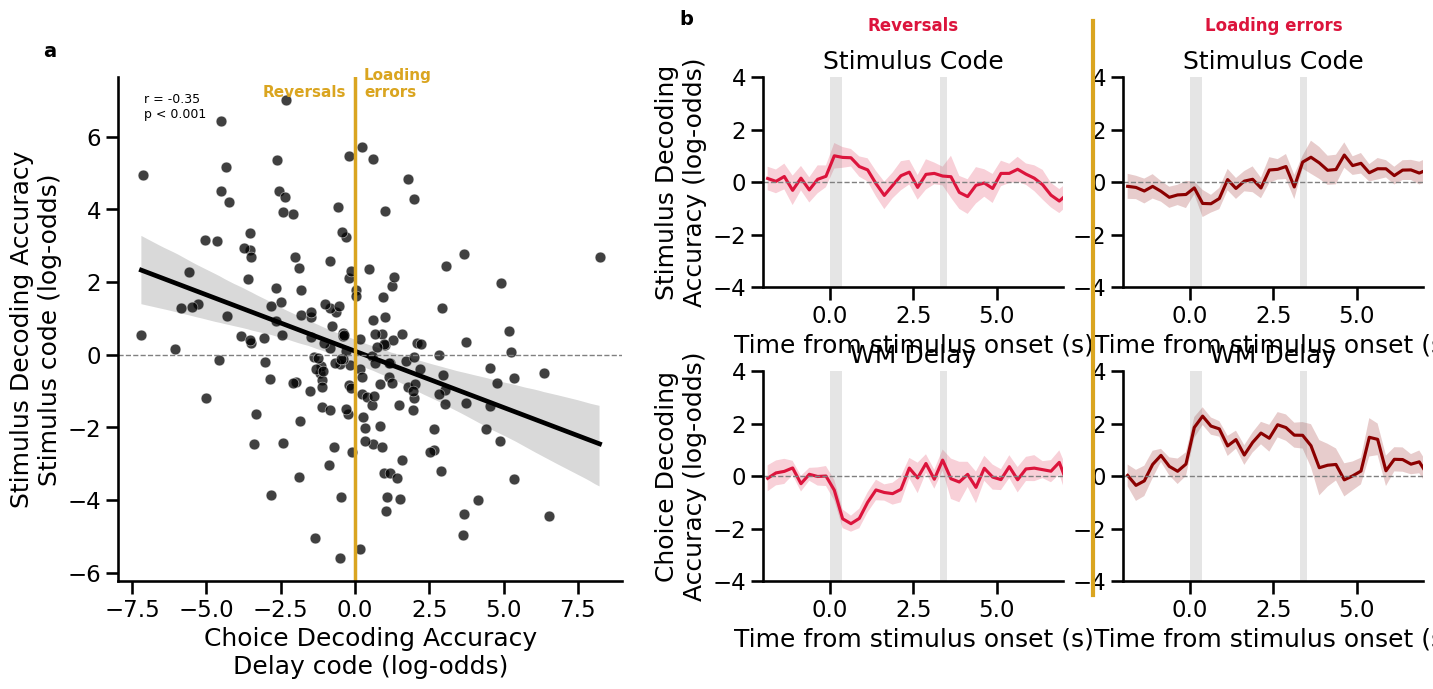

In [4]:
# 3-second delay
fig3 = plot_stim_wm_figure(merged_delay3, delay=3)
# fig3 = plot_stim_wm_figure(merged_delay3, delay=3, save_svg=r'G:\My Drive\...\stim_wm_delay3.svg')

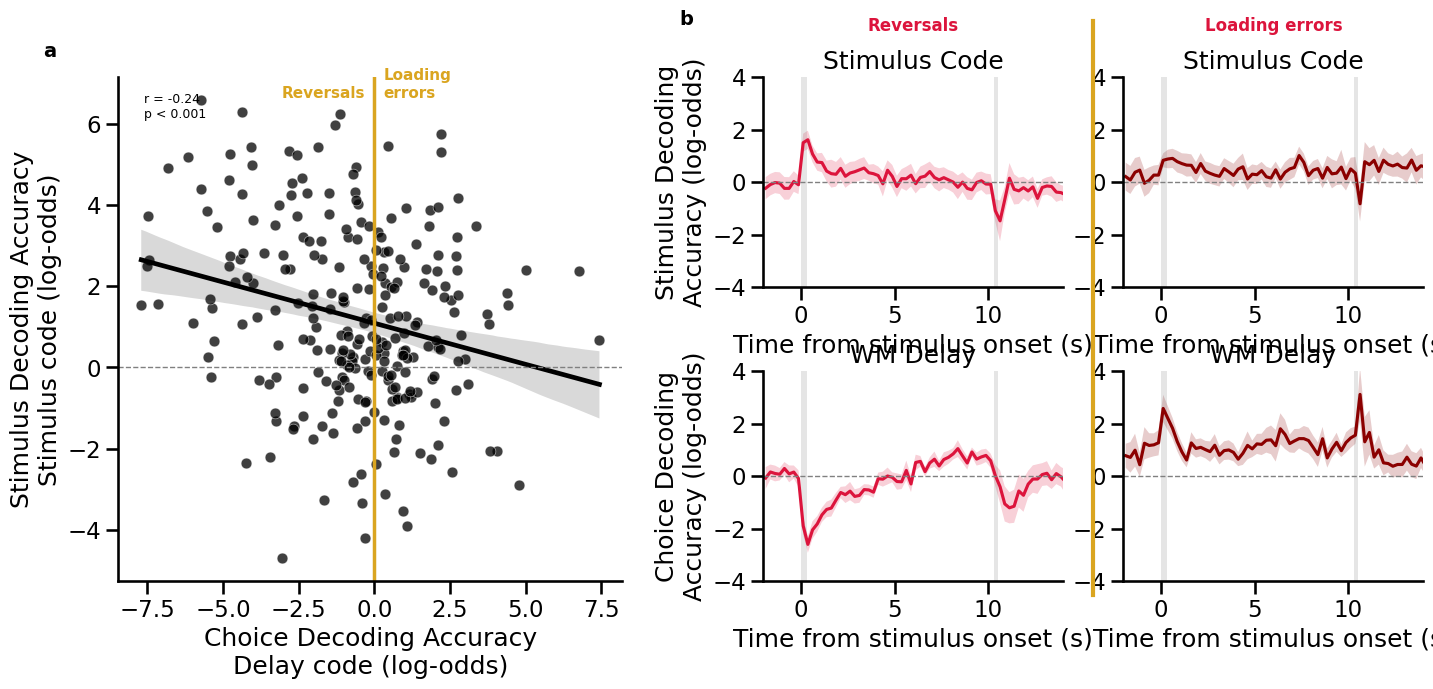

In [5]:
# 10-second delay
fig10 = plot_stim_wm_figure(merged_delay10, delay=10)
# fig10 = plot_stim_wm_figure(merged_delay10, delay=10, save_svg=r'G:\My Drive\...\stim_wm_delay10.svg')